<a href="https://colab.research.google.com/github/keivernunez/dataminingavanzado_austral/blob/main/Clase2_Note4_de_4_Perceptr%C3%B3n_Multicapa_(MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Perceptrón Multicapa (MLP)**

¡Bienvenidos, estudiantes de Minería de Datos e Inteligencia Artificial! En este cuaderno de Google Colab, exploraremos el Perceptrón Multicapa (MLP, por sus siglas en inglés), un tipo fundamental de red neuronal artificial. El MLP es especialmente útil para resolver problemas complejos y no lineales, como la clasificación en conjuntos de datos reales. Pensad en él como una versión avanzada del perceptrón simple: mientras que un perceptrón solo puede aprender fronteras de decisión lineales, un MLP puede capturar patrones mucho más intrincados en los datos. 🧠

En esencia, un MLP consta de al menos tres capas de nodos (neuronas):

* **Capa de Entrada**: Aquí la red recibe los datos iniciales. El número de neuronas en esta capa corresponde al número de características (o variables) en vuestro conjunto de datos.
* **Capas Ocultas**: Estas son las capas intermedias entre la entrada y la salida. Aquí ocurre la mayor parte del "aprendizaje". Al agregar más capas ocultas, aumentamos la complejidad de la red y su capacidad para aprender patrones complejos.
* **Capa de Salida**: Esta capa produce el resultado final de la computación de la red. El número de neuronas depende de la tarea específica, por ejemplo, una neurona para clasificación binaria o múltiples para clasificación multiclase.

Si una red tiene solo una capa oculta, se denomina **red neuronal superficial**. Si tiene más de una, se considera una **red neuronal profunda**, que es la base del aprendizaje profundo (deep learning).

Cada conexión entre neuronas tiene un "peso", un valor numérico que se ajusta durante el entrenamiento. Las operaciones fundamentales en la red son una serie de multiplicaciones matriciales que involucran estos pesos y las entradas, lo que las hace computacionalmente intensivas.

Para construir y entrenar un MLP, debéis definir varios componentes clave:

* **Número de capas ocultas**
* **Número de neuronas por capa oculta**
* **Función de activación**
* **Función de pérdida**
* **Algoritmo de retropropagación**

Es un error común pensar que una red más compleja siempre es mejor. Aunque las redes más profundas pueden capturar relaciones más complejas, también tardan más en entrenarse y son más propensas al **sobreajuste** (overfitting). El sobreajuste ocurre cuando el modelo aprende demasiado bien los datos de entrenamiento, incluyendo el ruido, y falla en generalizar a datos nuevos. Por otro lado, una red demasiado simple puede no capturar relaciones no lineales, lo que lleva a un bajo rendimiento.

### **Definiendo los Pesos de la Red Neuronal**

Consideremos un ejemplo simple. Los pesos de las conexiones se pueden representar mediante una matriz $\mathbf{W}$:

$$
\mathbf{W} = \begin{bmatrix}
w_{1,1} & w_{1,2} \\
w_{2,1} & w_{2,2} \\
w_{3,1} & w_{3,2}
\end{bmatrix}
$$

En esta matriz, cada fila corresponde a una característica de entrada y cada columna a una neurona en la siguiente capa. Las entradas se representan como un vector $\mathbf{X}$:

$$
\mathbf{X} = \begin{bmatrix}
x_{1} & x_{2} & x_{3}
\end{bmatrix}
$$

### **Funciones de Activación**

Las funciones de activación son un componente crucial de las redes neuronales. Introducen no linealidad en el modelo, permitiendo que aprenda de los errores y ajuste los pesos. Aquí hay algunas comunes:

* **Sigmoide**: Esta función comprime cualquier valor de entrada a un número entre 0 y 1. Se usa a menudo en la capa de salida para tareas de clasificación binaria.

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

* **ReLU (Unidad Lineal Rectificada)**: Es una de las funciones de activación más populares en el aprendizaje profundo. Es eficiente computacionalmente y ayuda a mitigar el problema del "gradiente desvaneciente". Devuelve 0 para entradas negativas y el valor de entrada para positivas.

$$f(x) = \max(0, x)$$

Ahora, ¡vamos a sumergirnos en el código y ver cómo funciona esto en la práctica!

In [ ]:
import os
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, roc_auc_score, roc_curve
from sklearn.neural_network import MLPClassifier

# Montar Google Drive para almacenar y acceder a archivos
drive.mount("/content/drive")
contentFolder = "/content/drive/MyDrive/Austral - Data Mining"
if not os.path.exists(contentFolder):
    os.mkdir(contentFolder)

Mounted at /content/drive


In [ ]:
# Cargar el conjunto de datos preprocesado del Titanic
data = pd.read_csv(f"{contentFolder}/titanicPreprocesada.txt", sep=";")

In [ ]:
# Preparar los datos para el entrenamiento
X = data.drop(columns=["index", "Survived"])
y = data["Survived"]
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Convertir a arrays de NumPy y escalar las características
X_train_np = X_train.values.astype(np.float32, order="C")
X_test_np = X_test.values.astype(np.float32, order="C")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)  # Usar transform en lugar de fit_transform para el conjunto de prueba

Y_train_np = Y_train.values
Y_test_np = Y_test.values

### **Modelo Construido Manualmente**

Comencemos construyendo una red neuronal desde cero para entender mejor los mecanismos subyacentes. Esto os ayudará a apreciar cómo funcionan las bibliotecas de alto nivel.

In [ ]:
# Definir las funciones de activación
def sigmoid_act(x, der=False):
    """Función de activación sigmoide."""
    if der:
        sig = 1 / (1 + np.exp(-x))
        return sig * (1 - sig)
    return 1 / (1 + np.exp(-x))

def ReLU_act(x, der=False):
    """Función de activación ReLU."""
    if der:
        return np.heaviside(x, 1)
    return np.maximum(x, 0)

In [ ]:
def ANN_train(X_train, Y_train, p=4, q=4, eta=0.0015):
    """Entrena una Red Neuronal Artificial simple."""
    w1 = 2 * np.random.rand(p, X_train.shape[1]) - 0.5
    b1 = np.random.rand(p)
    w2 = 2 * np.random.rand(q, p) - 0.5
    b2 = np.random.rand(q)
    wOut = 2 * np.random.rand(q) - 0.5
    bOut = np.random.random()  # Escalar para la salida

    mu = []
    vec_y = []

    for i in range(X_train.shape[0]):
        x = X_train[i]

        # Paso hacia adelante (feed-forward)
        z1 = ReLU_act(np.dot(w1, x) + b1)
        z2 = ReLU_act(np.dot(w2, z1) + b2)
        y = sigmoid_act(np.dot(wOut, z2) + bOut)  # y es escalar

        # Error en la capa de salida (para pérdida = (1/2)(y - t)^2)
        delta_Out = (y - Y_train[i]) * sigmoid_act(y, der=True)

        # Retropropagación
        delta_2 = delta_Out * wOut * ReLU_act(z2, der=True)
        delta_1 = np.dot(delta_2, w2) * ReLU_act(z1, der=True)

        # Descenso de gradiente
        wOut -= eta * delta_Out * z2
        bOut -= eta * delta_Out
        w2 -= eta * np.outer(delta_2, z1)  # Usar outer para mejor legibilidad
        b2 -= eta * delta_2
        w1 -= eta * np.outer(delta_1, x)
        b1 -= eta * delta_1

        # Calcular la pérdida
        mu.append(0.5 * (y - Y_train[i])**2)
        vec_y.append(y)

    # Calcular el promedio móvil de la pérdida para visualización
    batch_loss = np.convolve(np.array(mu), np.ones(10)/10, mode='valid')

    plt.figure(figsize=(10, 6))
    plt.plot(batch_loss, label='Error')
    plt.title('Pérdida Promedio por Época', fontsize=20)
    plt.xlabel('Época', fontsize=16)
    plt.ylabel('Pérdida', fontsize=16)
    plt.show()

    return w1, b1, w2, b2, wOut, bOut, mu

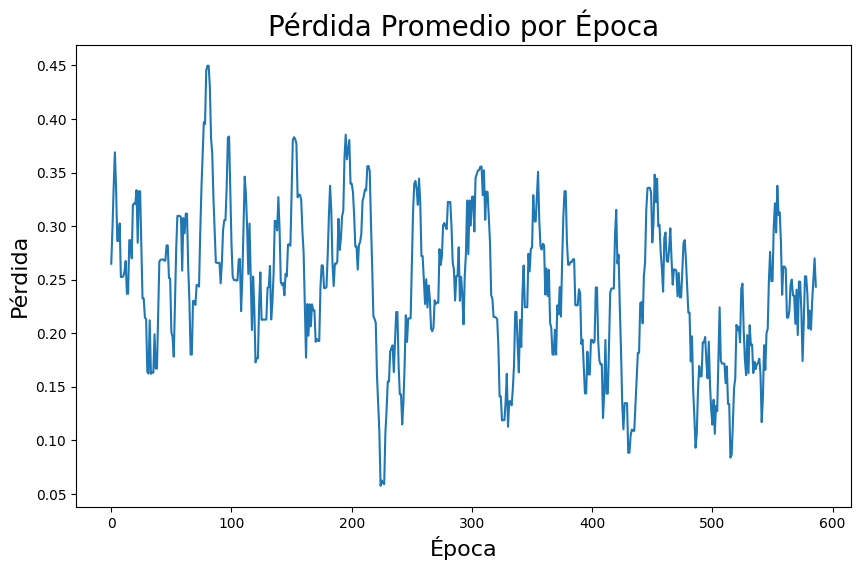

In [ ]:
w1, b1, w2, b2, wOut, bOut, mu = ANN_train(X_train_scaled, Y_train_np, p=8, q=4, eta=0.0015)

In [ ]:
def ANN_pred(X_test, w1, b1, w2, b2, wOut, bOut):
    """Realiza predicciones con la ANN entrenada."""
    pred = []
    for i in range(X_test.shape[0]):
        x = X_test[i]

        # Paso hacia adelante
        z1 = ReLU_act(np.dot(w1, x) + b1)
        z2 = ReLU_act(np.dot(w2, z1) + b2)
        y = sigmoid_act(np.dot(wOut, z2) + bOut)

        # Aplicar umbral para predicciones binarias
        pred.append(1 if y > 0.5 else 0)

    return np.array(pred)

def ANN_pred_proba(X_test, w1, b1, w2, b2, wOut, bOut):
    """Obtiene probabilidades de predicción de la ANN."""
    pred = []
    for i in range(X_test.shape[0]):
        x = X_test[i]

        # Paso hacia adelante
        z1 = ReLU_act(np.dot(w1, x) + b1)
        z2 = ReLU_act(np.dot(w2, z1) + b2)
        y = sigmoid_act(np.dot(wOut, z2) + bOut)

        pred.append(y)

    return np.array(pred)

In [ ]:
predictions = ANN_pred(X_test_scaled, w1, b1, w2, b2, wOut, bOut)
preds = ANN_pred_proba(X_test_scaled, w1, b1, w2, b2, wOut, bOut)

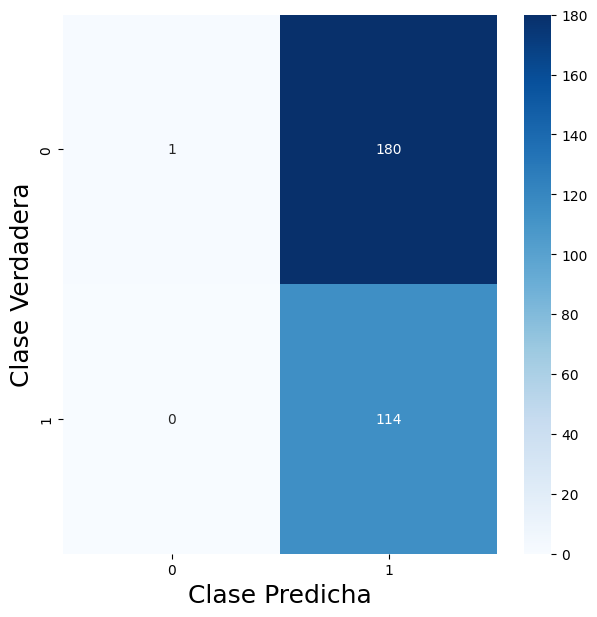

In [ ]:
# Graficar la matriz de confusión
cm = confusion_matrix(Y_test_np, predictions)

plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, cmap=plt.cm.Blues, fmt='g')
plt.xlabel("Clase Predicha", fontsize=18)
plt.ylabel("Clase Verdadera", fontsize=18)
plt.show()

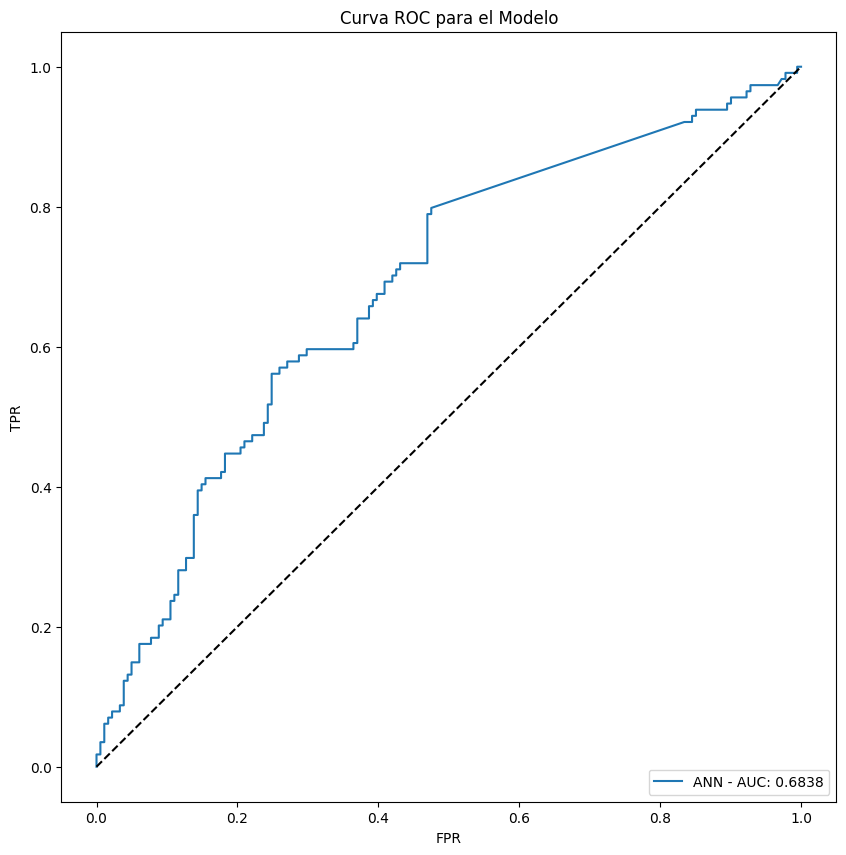

In [ ]:
# Graficar la curva ROC
plt.figure(figsize=(10, 10))
plt.title("Curva ROC para el Modelo")

areaBajoCurva = roc_auc_score(Y_test_np, preds)
fpr, tpr, _ = roc_curve(Y_test_np, preds)
plt.plot(fpr, tpr, label=f"ANN - AUC: {round(areaBajoCurva, 4)}")

plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], 'k--')  # Línea de referencia
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

### **Modelo con Scikit-learn**

Ahora, creemos un modelo más complejo usando `scikit-learn`. Usaremos dos capas ocultas, lo que nos introduce en el aprendizaje profundo. Esta biblioteca facilita la implementación y es ideal para prototipos rápidos en minería de datos.

In [ ]:
# Inicializar y entrenar el MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(16, 12), max_iter=300, activation='relu', solver='adam', random_state=1)
classifier.fit(X_train_scaled, Y_train_np)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(16, 12), max_iter=300, random_state=1)

In [ ]:
# Realizar predicciones
y_pred_sklearn = classifier.predict(X_test_scaled)
y_probas_sklearn = classifier.predict_proba(X_test_scaled)[:, 1]

In [ ]:
accuracy_score(Y_test_np, y_pred_sklearn)

0.8101694915254237

Esto debería daros una precisión alrededor del 81%. Analizad cómo varía con diferentes hiperparámetros.

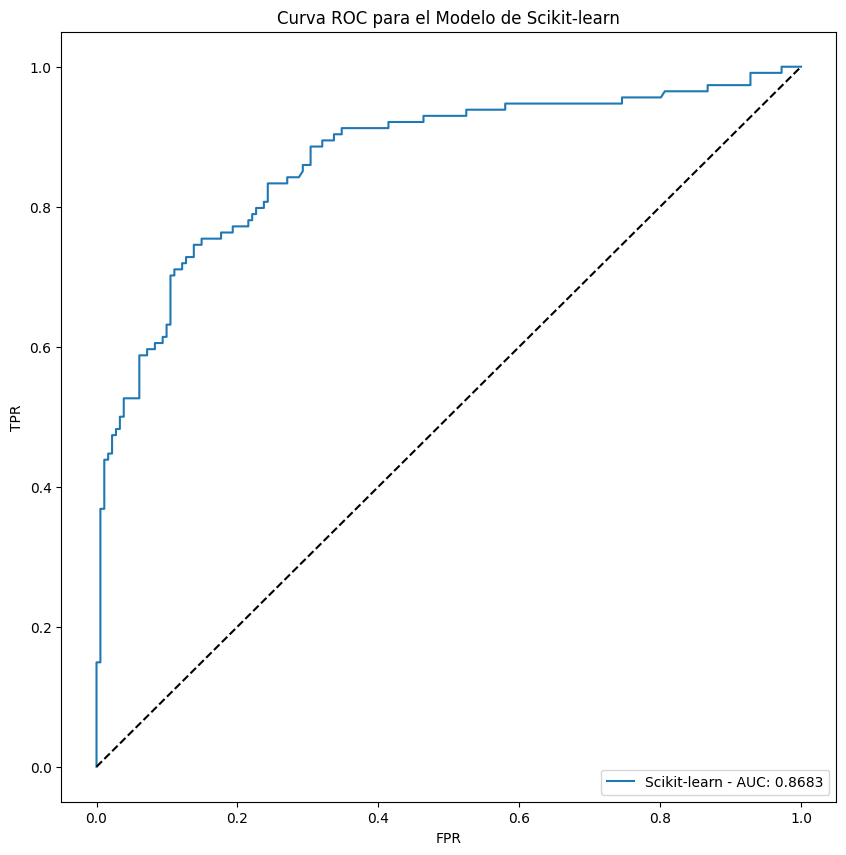

In [ ]:
# Graficar la curva ROC para el modelo de scikit-learn
plt.figure(figsize=(10, 10))
plt.title("Curva ROC para el Modelo de Scikit-learn")

areaBajoCurva_sklearn = roc_auc_score(Y_test_np, y_probas_sklearn)
fpr_sklearn, tpr_sklearn, _ = roc_curve(Y_test_np, y_probas_sklearn)
plt.plot(fpr_sklearn, tpr_sklearn, label=f"Scikit-learn - AUC: {round(areaBajoCurva_sklearn, 4)}")

plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

### **Modelo con Keras (con soporte para GPU)**

Para tareas de aprendizaje profundo más complejas, bibliotecas como Keras (integrada en TensorFlow) son ideales. Ofrecen más flexibilidad y pueden aprovechar GPUs para un entrenamiento más rápido. 🚀

Primero, asegurémonos de que TensorFlow esté instalado y pueda detectar vuestra GPU (si la tenéis).

In [ ]:
# Dependencias para el modelo de Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Verificar GPUs disponibles
print("Número de GPUs Disponibles: ", len(tf.config.list_physical_devices('GPU')))

# Construir la red neuronal con Keras
model = Sequential()
model.add(Dense(16, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

Número de GPUs Disponibles:  0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compilar el modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['auc'])

In [ ]:
# Entrenar el modelo y almacenar el historial
history = model.fit(X_train_scaled, Y_train_np, epochs=100, validation_data=(X_test_scaled, Y_test_np))

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc: 0.6362 - loss: 0.6859 - val_auc: 0.7110 - val_loss: 0.6409
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.7193 - loss: 0.6324 - val_auc: 0.7552 - val_loss: 0.6102
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.7520 - loss: 0.6054 - val_auc: 0.7772 - val_loss: 0.5851
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.7999 - loss: 0.5601 - val_auc: 0.7992 - val_loss: 0.5596
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.8081 - loss: 0.5500 - val_auc: 0.8170 - val_loss: 0.5382
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.8190 - loss: 0.5262 - val_auc: 0.8247 - val_loss: 0.5186
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.8315 - loss: 0.5068 - val_auc: 0.8297 - val_loss: 0.5023
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8255 - loss: 0.5032 - val_auc: 0.8299 - val_loss: 0.4931
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 

In [ ]:
# Realizar predicciones con el modelo de Keras
y_pred_keras = model.predict(X_test_scaled)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [ ]:
# Calcular y mostrar la precisión
a = accuracy_score((y_pred_keras > 0.5).astype(int).flatten(), Y_test_np)
print(f'La precisión es: {a * 100:.2f}%')

La precisión es: 81.36%


Deberíais ver una precisión alrededor del 80.68%. Experimentad con el número de épocas o capas para mejorar el rendimiento.

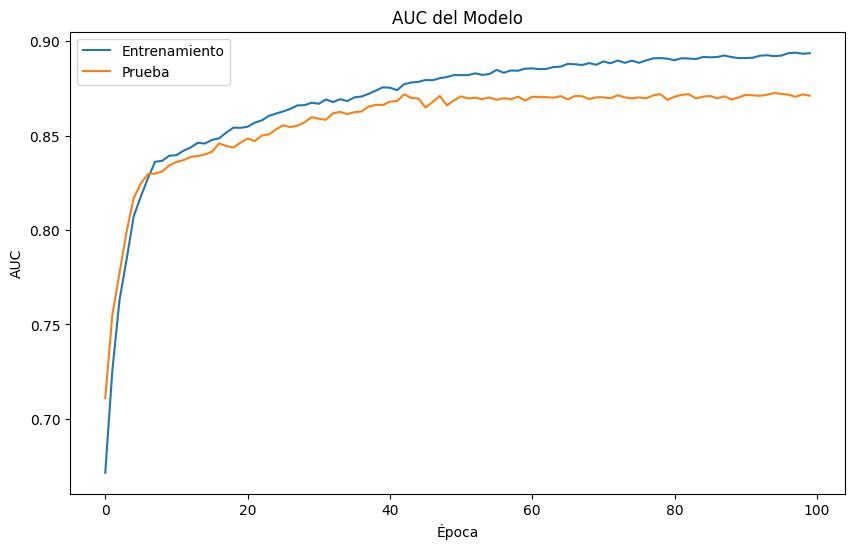

In [ ]:
# Graficar el AUC de entrenamiento y validación a lo largo de las épocas
plt.figure(figsize=(10, 6))
plt.plot(history.history['auc'])
plt.plot(history.history['val_auc'])
plt.title('AUC del Modelo')
plt.ylabel('AUC')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Prueba'], loc='upper left')
plt.show()

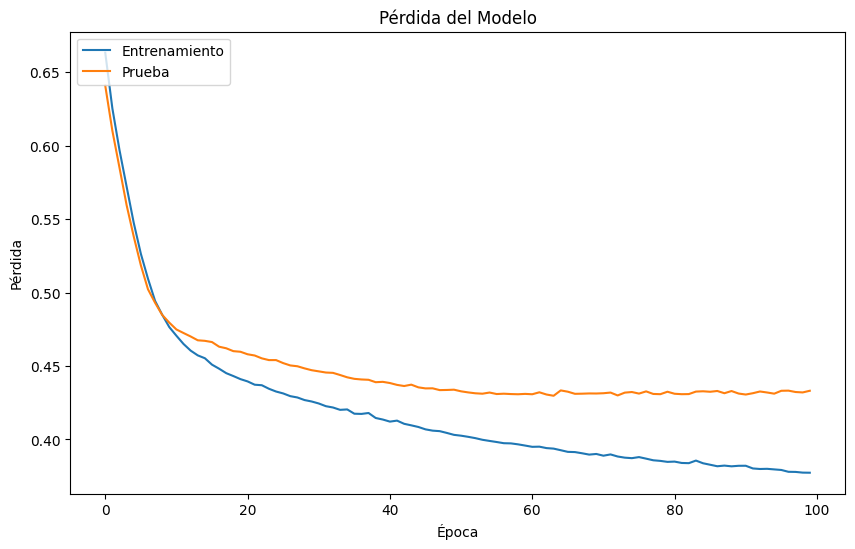

In [ ]:
# Graficar la pérdida de entrenamiento y validación a lo largo de las épocas
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Pérdida del Modelo')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend(['Entrenamiento', 'Prueba'], loc='upper left')
plt.show()

Al visualizar las métricas de entrenamiento y validación, podéis evaluar cómo aprende vuestro modelo y si hay sobreajuste. Este cuaderno ampliado os proporciona una comprensión más profunda de los Perceptrones Multicapa y cómo implementarlos de diferentes maneras.
